In [109]:
# from logit_model import *
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import tqdm
from statsmodels.stats.outliers_influence import variance_inflation_factor




In [41]:
pd.set_option('display.max_columns', None)

In [26]:
path = '../data/salary_sample_body_benefits.parquet.gzip'

In [43]:
if path[-3:] == 'csv:':
    even_sample = pd.read_csv(path)
elif path[-3:] == 'zip':
    even_sample = pd.read_parquet(path)

In [44]:
even_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,REMOTE_TYPE,REMOTE_TYPE_NAME,SKILLS,SKILLS_NAME,POSTED,LAST_UPDATED_DATE,ONET,ONET_NAME,ONET_2019,ONET_2019_NAME,SOC_2021_2_NAME,SOC_2021_2,MIN_YEARS_EXPERIENCE,COMPANY,COMPANY_NAME,COMPANY_RAW,AI ROLE,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry,CAREER_DEV,WLB,WELLBEING,RECOGNITION,FAMILY,CULTURE,EXPERIENCE_BUCKET,LOG_SALARY
0,b320dcdab94034000293d0c979dafd03543b828b,"San Jose, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS1200364C9C1LK3V5Q1"",\n ""KS1219W70LY1G...","[\n ""C (Programming Language)"",\n ""C++ (Prog...",2023-03-05,2024-03-26,15-2051.00,Data Scientists,15-2051.00,Data Scientists,Computer and Mathematical Occupations,15-0000,5.0,40227665,Viasat,Viasat,True,0.240,0.0,2023,194350.0,Machine Learning Engineer\n Viasat\n\n United ...,31.0,Manufacturing,False,False,False,False,False,True,3-5 years,12.177416
1,39036fb07ef90297a94c281b153ee88c6d71c514,"Memphis, TN","Shelby, TN",Tennessee,54,"Professional, Scientific, and Technical Services",Master's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS126L563YF9Y...","[\n ""Power BI"",\n ""Milestones (Project Manag...",2022-08-18,2024-04-19,13-1111.00,Management Analysts,13-1111.00,Management Analysts,Business and Financial Operations Occupations,13-0000,7.0,5732448,Deloitte,Deloitte,True,0.006,0.0,2022,135075.0,"Manager, People Analytics Deloitte - 3.9 Memph...",54.0,Professional and business services,False,True,True,False,False,False,6-10 years,11.813585
2,a81d1896d80873ed098d16225633e2c085c38b5b,"Detroit, MI","Wayne, MI",Michigan,44,Retail Trade,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS13USA80NE38XJHA2TL"",\n ""KS441726FF2HB...","[\n ""Power BI"",\n ""Target Audience"",\n ""Man...",2022-05-27,2024-04-19,15-2051.01,Business Intelligence Analysts,15-2051.01,Business Intelligence Analysts,Computer and Mathematical Occupations,15-0000,NaN,43639907,Dentsu,dentsu,True,0.002,0.0,2022,70962.0,"Careers in Analytics dentsu - 4.3 Detroit, MI ...",44.0,Retail trade,False,True,False,False,False,False,None Listed,11.169900
3,1031387a0b167843c4eba97e3d239c9aed4c7e19,"Grand Rapids, MI","Kent, MI",Michigan,53,Real Estate and Rental and Leasing,Bachelor's degree,1,Full-time (> 32 hours),False,1,Remote,"[\n ""KS122CH79G2KSBRRJHTN"",\n ""KS123HX69V95S...","[\n ""Contract Management"",\n ""Performance Ap...",2022-10-27,2024-03-26,11-3061.00,Purchasing Managers,11-3061.00,Purchasing Managers,Management Occupations,11-0000,5.0,6213303,CBRE,CBRE,True,0.959,1.0,2022,117050.0,JOB DETAILS\n\nJob Details\nProcurement Manage...,53.0,Financial activities,False,False,False,False,False,False,3-5 years,11.670356
4,85e918411cbf9017505845fb6b9aced339507afb,"New York, NY","New York, NY",New York,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,0,[None],"[\n ""ES4B99FD0FD70AC92985"",\n ""KS126L563YF9Y...","[\n ""Infrastructure Architecture"",\n ""Milest...",2019-09-16,2024-04-19,15-1251.00,Computer Programmers,15-1251.00,Computer Programmers,Computer and Mathematical Occupations,15-0000,2.0,34817379,Mobile Apps Company,Mobile Apps Company,True,0.043,0.0,2019,90000.0,Posted on\n\nEntry Level Software Programmer\n...,51.0,Information,False,False,False,False,False,False,1-2 years,11.407565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,a52ad16f54d407bdd566fff339ce0538584793f6,"Albany, OR","Linn, OR",Oregon,52,Finance and Insurance,No Education Listed,1,Full-time (> 32 hours),False,0,[None],"[\n ""KS121CT6DCXTRKRJF4RV"",\n ""KS1256K6CCY9P...","[\n ""Capital Requirements"",\n ""Insurance Pro...",2021-03-08,2023-12-14,41-3021.00,Insurance Sales Agents,41-3021.00,Insurance Sales Agents,Sal

In [46]:
region = 'STATE_NAME'
industry = 'NAICS_2022_2_NAME'
education = 'MIN_EDULEVELS_NAME'
year = 'YEAR'
occupation = 'SOC_2021_2_NAME'
experience = 'EXPERIENCE_BUCKET'

# Define Function

In [123]:
def run_logit_model(data, dependent, cat_controls=[], cont_controls = [], binary_vars = [], predictor = 'Has AI Skills', ref_category = None, get_vif = False):
    """
    Runs a logistic regression model to predict work-from-home dependent status based on the specified predictor
    and control variables.

    Parameters:
    -----------
    controls : list of str
        A list of column names to be used as control variables. These variables will be converted to categorical
        variables and dummy variables will be created for them.
    predictor : str, default='Has AI Skills'
        The column name of the primary predictor variable.
    data : pd.DataFrame, default=data
        The DataFrame containing the data.
    ref_category : dict, optional
        A dictionary specifying the reference category for each control variable where keys are column names
        and values are the reference categories.

    Returns:
    --------
    logit_model : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        The fitted logistic regression model.

    Example:
    --------
    >>> controls = ['region_column_name', 'industry_column_name']
    >>> model = run_wfh_logit(controls, predictor='Has AI Skills', data=data)
    >>> print(model.summary())
    """
    X = data[[predictor]]
    
    if binary_vars:
        for var in binary_vars:
            X = pd.concat([X, data[[var]]], axis = 1)
    
    if cont_controls:
        for cc in cont_controls:
            X = pd.concat([X, data[[cc]]], axis = 1)
    
    if cat_controls:
        for c in cat_controls:    
            # Create categorical variables 
            data[c] = data[c].astype('category')
            
            # Create dummy variables with specified reference category
            if ref_category and c in ref_category:
                # Ensure the reference category is present in the data
                if ref_category[c] in data[c].cat.categories:
                    data[c] = data[c].cat.reorder_categories(
                        [ref_category[c]] + [cat for cat in data[c].cat.categories if cat != ref_category[c]],
                        ordered=True
                    )
                    dummies = pd.get_dummies(data[c], drop_first=True)
            # Create dummy variables
                else:
                    raise ValueError(f"Reference category '{ref_category[c]}' not found in column '{c}'")
            else:
                dummies = pd.get_dummies(data[c], drop_first=True)
            X = pd.concat([X, dummies], axis = 1)

    X = X.apply(pd.to_numeric, errors='coerce')

    y = data[dependent]
    data = pd.concat([X, y], axis=1).dropna()
    X = data.drop(columns = dependent)
    y = data[dependent]
    X = sm.add_constant(X)
    y = pd.to_numeric(y, errors='coerce')

    X.columns = X.columns.astype(str)

    X = X.astype(float)
    y = y.astype(float)
    # print(X)
    # print(X.corr())
    
    if get_vif:
        print("VIF Results")
        vif_data = []
        for i in tqdm(range(X.shape[1]), desc="Calculating VIF"):
            vif = variance_inflation_factor(X.values, i)
            vif_data.append(vif)
        vif = pd.DataFrame()
        vif["features"] = X.columns
        vif["VIF"] = vif_data
        print(vif)
        print("Correlation Matrix")
        dummy_corr_matrix = X.corr()
        # print any correlations above 0.7
        print(dummy_corr_matrix[dummy_corr_matrix > 0.6])
        
    # if error, continue to next model
    try:
        logit_model = sm.Logit(y, X).fit()
    except Exception as error:
        # print error
        print(error)
        return "Error"

    # Print the summary of the model
    print(logit_model.summary())
    # print(summary_col(logit_model, stars=True, float_format='%0.2f'))
    return logit_model

# Models with Only Year and Occupation Control

In [30]:
benefits = ['CAREER_DEV', 'WLB', 'WELLBEING', 'RECOGNITION', 'FAMILY', 'CULTURE']


In [114]:
benefit_models = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation], get_vif = True)
    benefit_models.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 26.64it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

Calculating VIF: 100%|██████████| 29/29 [00:01<00:00, 27.78it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.261659
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19971
Method:                           MLE   Df Model:                           28
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                 0.07627
Time:                        11:26:28   Log-Likelihood:                -5233.2
converged:                      False   LL-Null:                       -5665.3
Covariance Type:            nonrobust   LLR p-value:                6.604e-164
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

Calculating VIF: 100%|██████████| 29/29 [00:00<00:00, 32.45it/s]


                                             features        VIF
0                                               const  60.589381
1                                             AI ROLE   1.829954
2                                                2020   2.031387
3                                                2021   2.625954
4                                                2022   3.126960
5                                                2023   3.479455
6   Arts, Design, Entertainment, Sports, and Media...   1.967929
7   Building and Grounds Cleaning and Maintenance ...   1.767230
8       Business and Financial Operations Occupations   4.531069
9            Community and Social Service Occupations   1.646147
10              Computer and Mathematical Occupations  10.432940
11            Construction and Extraction Occupations   1.669296
12    Educational Instruction and Library Occupations   1.892099
13         Farming, Fishing, and Forestry Occupations   1.033289
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [50]:
benefit_models = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation])
    benefit_models.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.510406
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CAREER_DEV   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19971
Method:                           MLE   Df Model:                           28
Date:                Mon, 07 Oct 2024   Pseudo R-squ.:                 0.02135
Time:                        17:20:53   Log-Likelihood:                -10208.
converged:                       True   LL-Null:                       -10431.
Covariance Type:            nonrobust   LLR p-value:                 1.101e-76
                                                      

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.080163
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            RECOGNITION   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19971
Method:                           MLE   Df Model:                           28
Date:                Mon, 07 Oct 2024   Pseudo R-squ.:                 0.04433
Time:                        17:20:55   Log-Likelihood:                -1603.3
converged:                      False   LL-Null:                       -1677.6
Covariance Type:            nonrobust   LLR p-value:                 2.087e-18
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.261659
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19971
Method:                           MLE   Df Model:                           28
Date:                Mon, 07 Oct 2024   Pseudo R-squ.:                 0.07627
Time:                        17:20:55   Log-Likelihood:                -5233.2
converged:                      False   LL-Null:                       -5665.3
Covariance Type:            nonrobust   LLR p-value:                6.604e-164
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.294405
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                CULTURE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19971
Method:                           MLE   Df Model:                           28
Date:                Mon, 07 Oct 2024   Pseudo R-squ.:                 0.09098
Time:                        17:20:56   Log-Likelihood:                -5888.1
converged:                      False   LL-Null:                       -6477.5
Covariance Type:            nonrobust   LLR p-value:                1.902e-230
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
# export benefit_models to pickle
import pickle
if path[-3:] == 'csv:':
    with open('../exports/benefit_models.pkl', 'wb') as f:
        pickle.dump(benefit_models, f)
elif path == '../data/salary_sample_body_benefits.parquet.gzip'
    with open('../exports/benefit_models_fromlarge.pkl', 'wb') as f:
        pickle.dump(benefit_models, f)

# With Individual Controls

In [124]:
benefit_models_2 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education],  ref_category = {education: "No Education Listed", experience: 'None Listed'}, get_vif = True)
    benefit_models_2.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
VIF Results


Calculating VIF:   0%|          | 0/34 [00:00<?, ?it/s]

Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 31.34it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 21.38it/s]


...

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.261099
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19966
Method:                           MLE   Df Model:                           33
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                 0.07825
Time:                        11:39:08   Log-Likelihood:                -5222.0
converged:                      False   LL-Null:                       -5665.3
Covariance Type:            nonrobust   LLR p-value:                6.232e-165
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

Calculating VIF: 100%|██████████| 34/34 [00:01<00:00, 22.28it/s]


                                             features        VIF
0                                               const  62.954785
1                                             AI ROLE   1.944705
2                                                2020   2.031696
3                                                2021   2.632953
4                                                2022   3.133764
5                                                2023   3.489583
6   Arts, Design, Entertainment, Sports, and Media...   1.981853
7   Building and Grounds Cleaning and Maintenance ...   1.796928
8       Business and Financial Operations Occupations   4.537507
9            Community and Social Service Occupations   1.657658
10              Computer and Mathematical Occupations  10.469568
11            Construction and Extraction Occupations   1.695833
12    Educational Instruction and Library Occupations   1.903057
13         Farming, Fishing, and Forestry Occupations   1.033577
14   Food Preparation and

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [125]:
benefit_models_2

 'Error',

In [65]:
pd.set_option('display.max_rows', 100)

In [61]:
even_sample.groupby([occupation, education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_59189/3366778209.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, education]).size()


SOC_2021_2_NAME                                             MIN_EDULEVELS_NAME          
Architecture and Engineering Occupations                    No Education Listed               67
                                                            Associate degree                  29
                                                            Bachelor's degree                271
                                                            High school or GED                39
                                                            Master's degree                   13
                                                            Ph.D. or professional degree      10
Arts, Design, Entertainment, Sports, and Media Occupations  No Education Listed              210
                                                            Associate degree                  21
                                                            Bachelor's degree                138
                                      

In [62]:
even_sample.groupby([occupation, experience]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_59189/2438234741.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby([occupation, experience]).size()


SOC_2021_2_NAME                                             EXPERIENCE_BUCKET
Architecture and Engineering Occupations                    None Listed           122
                                                            0 years                 6
                                                            1-2 years              62
                                                            11-20 years            19
                                                            3-5 years             135
                                                            6-10 years             85
Arts, Design, Entertainment, Sports, and Media Occupations  None Listed           229
                                                            0 years                17
                                                            1-2 years              67
                                                            11-20 years             6
                                                            3-

In [63]:
even_sample.groupby(['AI ROLE', education]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_59189/2998860356.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby(['AI ROLE', education]).size()


AI ROLE  MIN_EDULEVELS_NAME          
False    No Education Listed             5046
         Associate degree                 475
         Bachelor's degree               1516
         High school or GED              2743
         Master's degree                  143
         Ph.D. or professional degree      77
True     No Education Listed             2537
         Associate degree                 307
         Bachelor's degree               5668
         High school or GED               626
         Master's degree                  618
         Ph.D. or professional degree     244
dtype: int64

In [64]:
even_sample.groupby(['AI ROLE', experience]).size()

/var/folders/5k/j3bfrd8s2_l092hd5snmdbzm0000gn/T/ipykernel_59189/3962998664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  even_sample.groupby(['AI ROLE', experience]).size()


AI ROLE  EXPERIENCE_BUCKET
False    None Listed          5571
         0 years               513
         1-2 years            2165
         11-20 years            45
         3-5 years            1363
         6-10 years            343
True     None Listed          2747
         0 years               150
         1-2 years            1048
         11-20 years           360
         3-5 years            3336
         6-10 years           2359
dtype: int64

In [ ]:
import pickle
if path[-3:] == 'csv:':
    with open('../exports/benefit_models_2.pkl', 'wb') as f:
        pickle.dump(benefit_models_2, f)
elif path == '../data/salary_sample_body_benefits.parquet.gzip'
    with open('../exports/benefit_models_fromlarge_2.pkl', 'wb') as f:
        pickle.dump(benefit_models_2, f)

# With Salary Control

In [135]:
benefit_models_3 = []
for benefit in benefits:
    print(benefit)
    print('--'*100)
    model = run_logit_model(even_sample, dependent = benefit, predictor='AI ROLE', cat_controls = [year, occupation, education, experience], cont_controls = ['LOG_SALARY'], ref_category = {education: "No Education Listed", experience: 'None Listed'})
    benefit_models_3.append(model)

CAREER_DEV
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.507065
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CAREER_DEV   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                 0.02776
Time:                        11:47:10   Log-Likelihood:                -10141.
converged:                       True   LL-Null:                       -10431.
Covariance Type:            nonrobust   LLR p-value:                 2.455e-97
                                                      

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Singular matrix
RECOGNITION
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
         Current function value: 0.078110
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            RECOGNITION   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                 0.06880
Time:                        11:47:13   Log-Likelihood:                -1562.2
converged:                      False   LL-Null:                       -1677.6
Covariance Type:            nonrobust   LLR p-value:                 4.537e-29
            

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.260912
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 FAMILY   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                 0.07891
Time:                        11:47:14   Log-Likelihood:                -5218.2
converged:                      False   LL-Null:                       -5665.3
Covariance Type:            nonrobust   LLR p-value:                2.861e-162
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.286980
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                CULTURE   No. Observations:                20000
Model:                          Logit   Df Residuals:                    19960
Method:                           MLE   Df Model:                           39
Date:                Tue, 08 Oct 2024   Pseudo R-squ.:                  0.1139
Time:                        11:47:15   Log-Likelihood:                -5739.6
converged:                      False   LL-Null:                       -6477.5
Covariance Type:            nonrobust   LLR p-value:                1.523e-284
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const                                           

/Users/alejandracastaneda/anaconda3/envs/thesisenv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [136]:
benefit_models_3

 'Error',

# Plot Coefficients

In [88]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models:
    # Extract the coefficient and standard error for 'AI_skill'
    coef = model.params['AI ROLE']
    err = model.bse['AI ROLE']
    pvalue = model.pvalues['AI ROLE'].round(3)
    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df = pd.DataFrame(results)



In [ ]:
results_df

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,0.116036,0.048395,0.016
1,WLB,-0.248177,0.050078,0.000
2,WELLBEING,0.294897,0.090546,0.001
3,RECOGNITION,-0.114419,0.101180,0.258
4,FAMILY,0.612483,0.096137,0.000
5,CULTURE,0.767740,0.064419,0.000


In [89]:
results_df['Model Iteration'] = 'Baseline'

In [90]:
results_df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.038875,0.046256,0.401,Baseline
1,WLB,-0.170518,0.040277,0.000,Baseline
2,WELLBEING,0.397974,0.077556,0.000,Baseline
3,RECOGNITION,0.094436,0.154843,0.542,Baseline
4,FAMILY,0.439232,0.072141,0.000,Baseline
5,CULTURE,0.603393,0.068558,0.000,Baseline


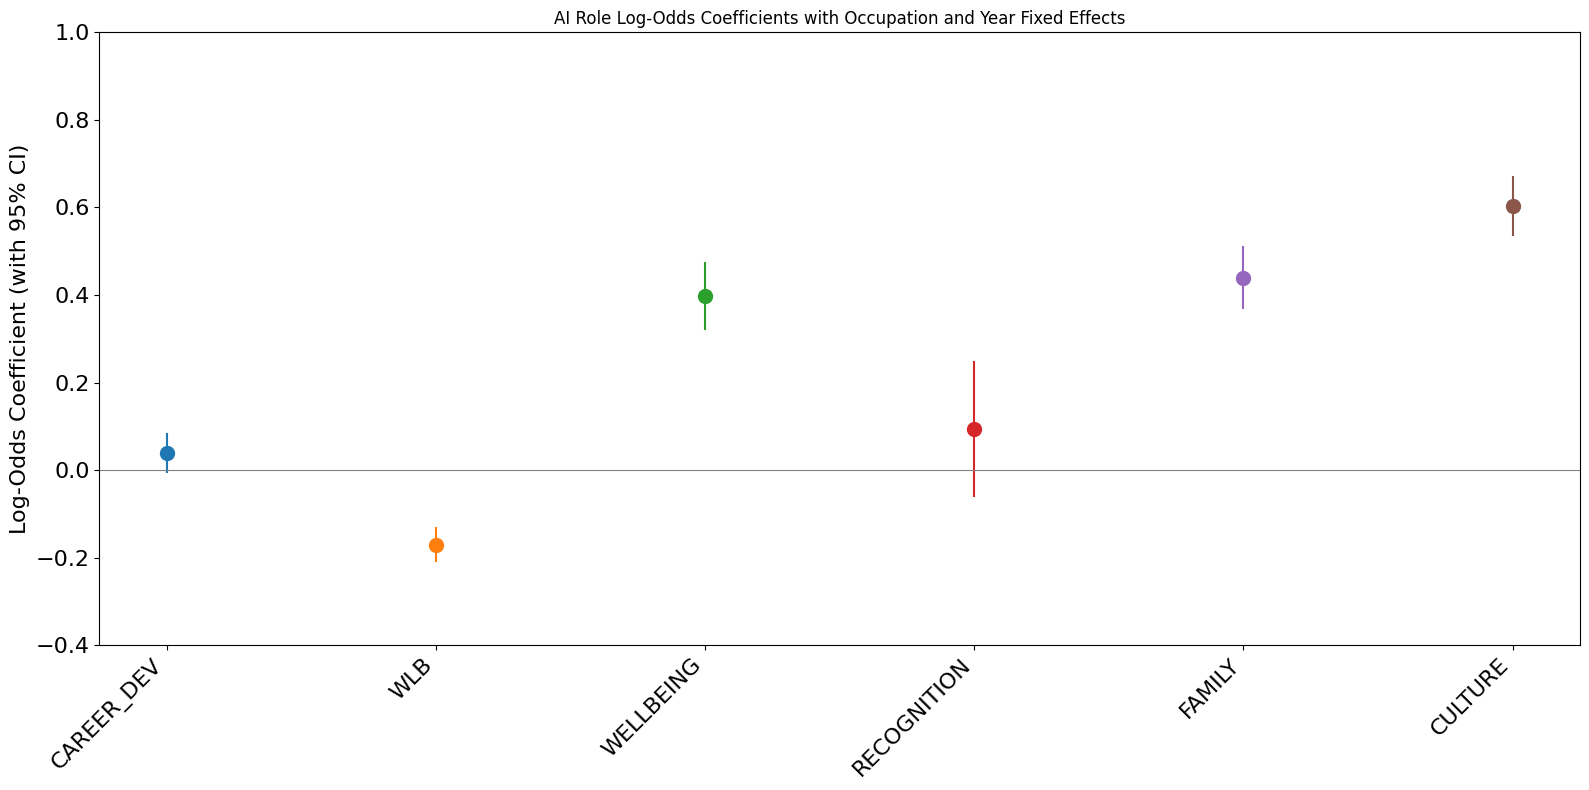

In [71]:
fig, ax = plt.subplots(figsize=(16, 8))
# Define colors for the 9 AI skills categories
# colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(len(results_df))]
# Plot each AI skill category
for i, row in results_df.iterrows():
    ax.errorbar(
        i, row['Coefficient'], 
        yerr=row['Error'], 
        fmt='o', color=colors[i], label=row['Label'], markersize = 10
    )

# Customize plot
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['Label'], rotation=45, ha='right', fontsize = 16)
# ax.set_title('Coefficients for 9 AI Skills Categories')
# ax.set_xlabel('AI Skills Categories', fontsize = 18)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize = 16)
ax.axhline(0, color='grey', linewidth=0.8)
# ax.axhline(average_coefficient, color='grey', linestyle='--', linewidth=1, label='Average Coefficient')

# Increase the size of y-ticks
ax.tick_params(axis='y', labelsize=16)
ax.set_title('AI Role Log-Odds Coefficients with Occupation and Year Fixed Effects')
ax.set_ylim(-0.4, 1.0)
# Add legend
# ax.legend(title='AI Skills', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 16, title_fontsize = 16)

plt.tight_layout() 
plt.show()

In [128]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_2:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_2 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_2 = pd.DataFrame(results_2)



In [129]:
results_df_2

,Label,Coefficient,Error,P-Value
0,CAREER_DEV,-0.013798,0.047969,0.774
1,WLB,-0.177028,0.041706,0.000
2,WELLBEING,0.291055,0.080202,0.000
3,RECOGNITION,NaN,NaN,NaN
4,FAMILY,0.466265,0.074534,0.000
5,CULTURE,0.499047,0.070634,0.000


In [130]:
results_df_2['Model Iteration'] = 'Individual Controls'

In [138]:
coefficients = []
errors = []
pvalues = []
for model in benefit_models_3:
    try:
        coef = model.params['AI ROLE']
        err = model.bse['AI ROLE']
        pvalue = model.pvalues['AI ROLE'].round(3)
    except:
        coef = None
        err = None
        pvalue = None

    coefficients.append(coef)
    errors.append(err)
    pvalues.append(pvalue)

# Creating DataFrame
results_3 = {
    'Label': benefits,
    'Coefficient': coefficients,
    'Error': errors,
    'P-Value': pvalues
}

results_df_3 = pd.DataFrame(results_3)



In [139]:
results_df_3['Model Iteration'] = 'With Salary'

In [140]:
df = pd.concat([results_df, results_df_2, results_df_3])

In [141]:
df

,Label,Coefficient,Error,P-Value,Model Iteration
0,CAREER_DEV,0.038875,0.046256,0.401,Baseline
1,WLB,-0.170518,0.040277,0.000,Baseline
2,WELLBEING,0.397974,0.077556,0.000,Baseline
3,RECOGNITION,0.094436,0.154843,0.542,Baseline
4,FAMILY,0.439232,0.072141,0.000,Baseline
5,CULTURE,0.603393,0.068558,0.000,Baseline
0,CAREER_DEV,-0.013798,0.047969,0.774,Individual Controls
1,WLB,-0.177028,0.041706,0.000,Individual Controls
2,WELLBEING,0.291055,0.080202,0.000,Individual Controls
3,RECOGNITION,NaN,NaN,NaN,Individual Controls


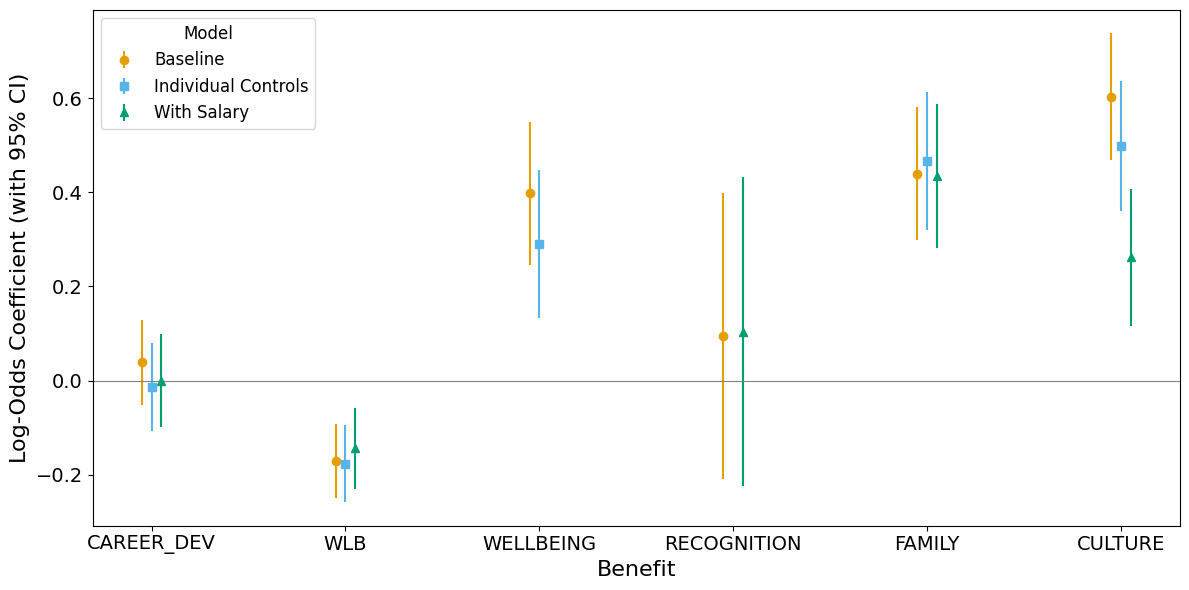

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each model
colors = ['#E69F00', '#56B4E9', '#009E73', '#CC79A7']
# Calculate the 95% confidence intervals
df['Lower_CI'] = df['Coefficient'] - 1.96 * df['Error']
df['Upper_CI'] = df['Coefficient'] + 1.96 * df['Error']

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# benefits = benefits
model_iterations = df['Model Iteration'].unique()
markers = ['o', 's', '^']  # Different markers for model iterations
positions = []
current_pos = 0

# Store legend handles and labels to avoid duplicates
handles, labels = [], []

for benefit in benefits:
    benefit_data = df[df['Label'] == benefit]
    benefit_positions = []
    for i, model in enumerate(model_iterations):
        model_data = benefit_data[benefit_data['Model Iteration'] == model]
        if not model_data.empty:
            pos = current_pos + i * 0.2  # Adjust spacing between model_iterations within the same benefit
            handle = ax.errorbar(
                pos, model_data['Coefficient'].values, 
                yerr=[model_data['Coefficient'].values - model_data['Lower_CI'].values, 
                      model_data['Upper_CI'].values - model_data['Coefficient'].values], 
                fmt=markers[i], color=colors[i], label=model if benefit == benefits[0] else ""
            )
            benefit_positions.append(pos)
            if benefit == benefits[0]:  # Add handles and labels only for the first benefit to avoid duplicates
                handles.append(handle)
                labels.append(model)
    positions.extend(benefit_positions)
    current_pos += len(model_iterations) + 1  # Add more space between different benefits

# Customize plot
benefit_ticks = [(positions[i * len(model_iterations)] + positions[(i + 1) * len(model_iterations) - 1]) / 2 for i in range(len(benefits))]
ax.set_xticks(benefit_ticks)
ax.tick_params(axis='y', labelsize=14)
ax.set_xticklabels(benefits, rotation=0, fontsize = 14)
# ax.set_title('AI Skill Coefficients by benefit and Occupation')
ax.set_xlabel('Benefit', fontsize=16)
ax.set_ylabel('Log-Odds Coefficient (with 95% CI)', fontsize=16)
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend(handles, labels, title='Model', bbox_to_anchor=(0, 1), loc = 'upper left', fontsize = 12, title_fontsize = 12)
# ax.axhline(average_coefficient, color='black', linestyle='--', linewidth=1, label='Average Coefficient')

plt.tight_layout()
plt.show()
